# Data Visualization
This notebook includes plots to include in the report

In [1]:
import pandas as pd
from src.config import get_config
from src.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

config = get_config()

The below cell takes some time to run as it loads a bunch of data

In [2]:
loader = DataLoader(data_path = "../data")

# Get option data from
query = (
    f"SELECT {', '.join(config.relevant_option_columns)} FROM options_enriched"
    f" WHERE date >= '{config.start_date}' AND date <= '{config.end_date}'"
    f" AND tte_days <= {config.max_tte}"
    f" AND ((cp_flag == 'C' AND log_moneyness >= 0) OR (cp_flag == 'P' AND log_moneyness < 0))"
)
df = loader.query(query)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## Missing values

In [3]:
df.head()

,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,strike_price,best_bid,best_offer,...,mid_price,spread,tte_days,tte,tte_months,spot_price,risk_free_rate,forward_price,spread_pct,log_moneyness
0,103049.0,2013-07-12,C 130720C52500,1,2013-07-20,2013-07-12,C,52500.0,0.28,0.29,...,0.285,0.01,8,0.021918,1.0,50.81,0.000273,50.810304,0.035088,0.032714
1,103049.0,2013-07-12,C 130720C55000,1,2013-07-20,2013-07-12,C,55000.0,0.04,0.06,...,0.050,0.02,8,0.021918,1.0,50.81,0.000273,50.810304,0.400000,0.079234
2,103049.0,2013-07-12,C 130720C57500,1,2013-07-20,2013-07-12,C,57500.0,0.01,0.03,...,0.020,0.02,8,0.021918,1.0,50.81,0.000273,50.810304,1.000000,0.123686
3,103049.0,2013-07-12,C 130720C60000,1,2013-07-20,2013-07-12,C,60000.0,0.01,0.03,...,0.020,0.02,8,0.021918,1.0,50.81,0.000273,50.810304,1.000000,0.166245
4,103049.0,2013-07-12,C 130720C62500,1,2013-07-20,2013-06-12,C,62500.0,0.00,0.01,...,0.005,0.01,8,0.021918,1.0,50.81,0.000273,50.810304,2.000000,0.207067


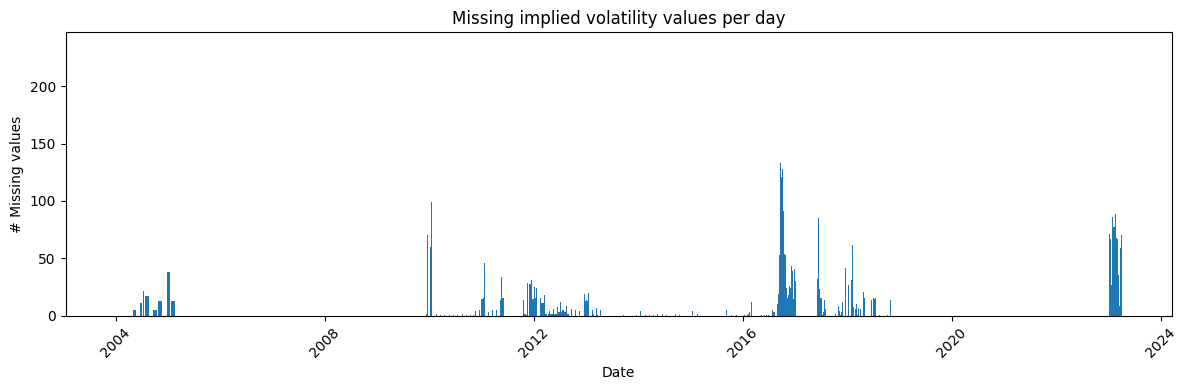

In [4]:
# nan_visualizing = df.loc[df['impl_volatility'].isna(), ['date', 'impl_volatility']].groupby(by='date').transform('count')
nan_per_day = df[df['impl_volatility'].isna()].groupby('date')['impl_volatility'].size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(nan_per_day.index, nan_per_day.values)
ax.set_xlabel("Date")
ax.set_ylabel("# Missing values")
ax.set_title("Missing implied volatility values per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/data_visualization/missing_values_per_day.png')
plt.show()

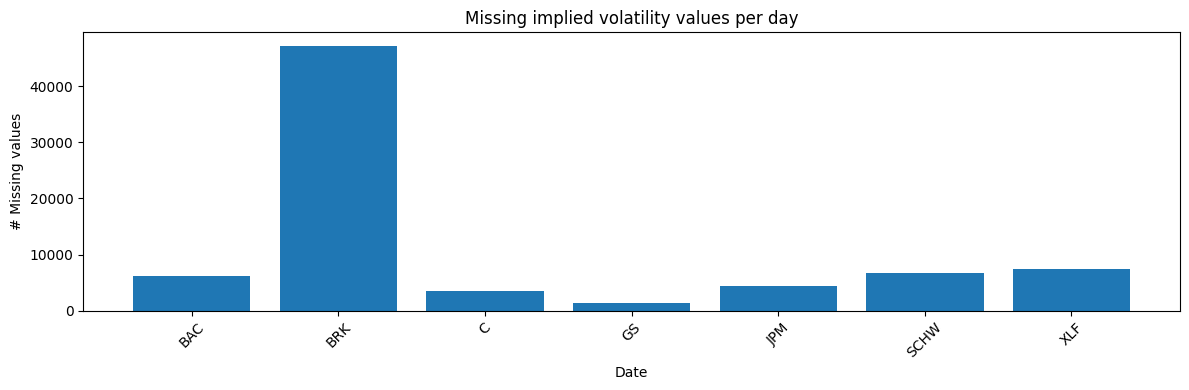

In [5]:
nan_per_day = df[df['impl_volatility'].isna()].groupby('ticker')['impl_volatility'].size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(nan_per_day.index, nan_per_day.values)
ax.set_xlabel("Date")
ax.set_ylabel("# Missing values")
ax.set_title("Missing implied volatility values per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/data_visualization/missing_values_per_ticker.png')
plt.show()

## Largest Values

In [6]:
df.nlargest(10, 'impl_volatility')[['date', 'ticker', 'impl_volatility', 'tte_days']]

,date,ticker,impl_volatility,tte_days
1654991,2011-12-22,C,8.998517,1
324815,2013-07-19,XLF,8.998424,1
1202459,2016-08-24,BAC,8.994681,2
1303657,2007-10-19,SCHW,8.993869,1
1131544,2012-03-16,XLF,8.990587,1
1300566,2006-06-14,SCHW,8.986868,3
2890260,2022-01-20,XLF,8.984201,1
1201843,2016-08-18,BAC,8.981589,1
2888688,2022-01-06,XLF,8.977474,1
2032288,2013-04-09,BAC,8.976634,3


## Spreads

In [7]:
df.loc[:, 'spread_pct'] = df['spread_pct']*100

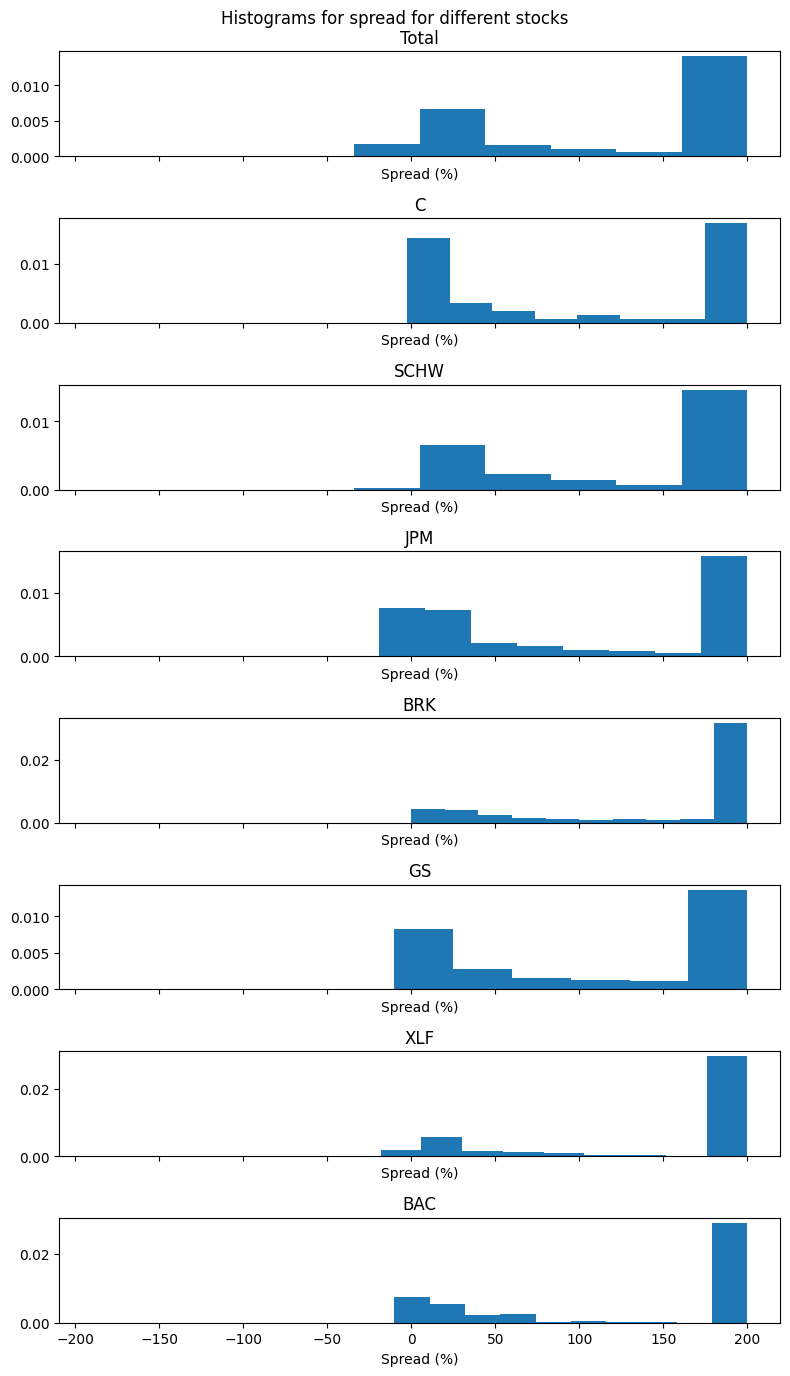

In [8]:
tickers = df.ticker.unique()
fig, axs = plt.subplots(len(tickers) + 1, figsize=(8, 14), sharex=True)
axs[0].hist(df.spread_pct, density=True)
axs[0].set_title('Total')
axs[0].set_xlabel('Spread (%)')
for idx, ticker in enumerate(tickers):
    axs[idx + 1].hist(df.loc[df['ticker'] == ticker, 'spread_pct'], density=True)
    axs[idx + 1].set_title(ticker)
    axs[idx + 1].set_xlabel('Spread (%)')
fig.suptitle('Histograms for spread for different stocks')
fig.tight_layout()
plt.savefig('../plots/data_visualization/spread_pct.png')
plt.show()

In [9]:
desc = (df.groupby(by='ticker')['spread_pct']).describe()
latex_table = desc.to_latex(
    float_format="%.2f",   # Format floats to 4 decimal places
    caption="Spread Percentage Statistics by Ticker",
    label="tab:pct_spread",
    bold_rows=True,
    escape=True
)

print(latex_table)

\begin{table}
\caption{Spread Percentage Statistics by Ticker}
\label{tab:pct_spread}
\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25\% & 50\% & 75\% & max \\
ticker &  &  &  &  &  &  &  &  \\
\midrule
\textbf{BAC} & 428968.00 & 133.26 & 85.63 & -10.00 & 28.57 & 200.00 & 200.00 & 200.00 \\
\textbf{BRK} & 429650.00 & 149.98 & 72.40 & 0.00 & 81.25 & 200.00 & 200.00 & 200.00 \\
\textbf{C} & 533180.00 & 103.58 & 88.31 & -52.99 & 10.69 & 80.00 & 200.00 & 200.00 \\
\textbf{GS} & 604075.00 & 116.00 & 85.27 & -150.00 & 18.18 & 142.86 & 200.00 & 200.00 \\
\textbf{JPM} & 563541.00 & 104.47 & 88.22 & -73.68 & 11.11 & 85.71 & 200.00 & 200.00 \\
\textbf{SCHW} & 326429.00 & 133.62 & 79.78 & -190.00 & 40.00 & 200.00 & 200.00 & 200.00 \\
\textbf{XLF} & 451912.00 & 153.55 & 76.65 & -42.42 & 85.71 & 200.00 & 200.00 & 200.00 \\
\bottomrule
\end{tabular}
\end{table}

